In [1]:
from ortools.sat.python import cp_model

In [2]:
# import random
# random.seed(42)
# nodes = {
#     0: (0, 0), 1: (2, 5), 2: (8, 3), 3: (5, 9), 4: (1, 7),
#     5: (6, 4), 6: (9, 9), 7: (3, 1), 8: (7, 8), 9: (4, 4)
# }
# N = list(nodes.keys())
# Q = 9
# D = [8, 1]
# C = [i for i in nodes.keys() if i not in D]
# K = range(4)
# q = {i: random.randint(1,5) for i in C}

In [3]:
import random
import pandas as pd
from random import randint
random.seed(1)
df = pd.read_excel("data/points.xlsx")
nodes = {int(row["node"]): (row["x"], row["y"]) for i, row in df.head(19).iterrows()}


N = list(nodes.keys())
Q = 25
D = [0, 10]
C = [i for i in nodes.keys() if i not in D]
K = range(3)
q = {i: random.randint(1,5) for i in C}


In [4]:
import math
distance = {}
for i in (N):
    for j in (N):
        if i == j:
            distance[i,j] = 0
        else:
            xi,yi = nodes[i]
            xj,yj = nodes[j]
            dx, dy = xi-xj , yi-yj
            distance[i,j] = math.hypot(dx,dy)

In [5]:
model = cp_model.CpModel()

In [6]:
z = {
    (i,k) : model.NewBoolVar(f"z[{i},{k}]")
    for i in C
    for k in K
}
w = {
    (d,k): model.NewBoolVar(f"w[{d},{k}]")
    for d in D
    for k in K
}

y = {
   k: model.NewBoolVar(f"y[{k}]") 
    for k in K
}

In [7]:
# (1) customer assignment 
for i in C:
    model.AddExactlyOne([z[i,k] for k in K])

In [8]:
# (2) vehicle-depo assignment
for k in K:
    model.Add(sum(w[d,k] for d in D)==y[k])

In [9]:
# capacity
for k in K:
    model.Add(sum(q[i]*z[i,k] for i in C) <= y[k]*Q)

In [10]:
x = {}
for k in K:
    arcs = []
    for i in N:
        for j in N:
            if i != j:
                x[i,j,k] = model.NewBoolVar(f"x[{i},{j},{k}]")
                arcs.append((i,j,x[i,j,k]))
            else:# i == j:
                if i in C:
                    x[i,i,k] = z[i,k].Not()
                elif i in D:
                    x[i,i,k] = w[i,k].Not()
                    
                arcs.append((i,i,x[i,i,k]))
    model.AddCircuit(arcs)
            

In [12]:
model.Minimize(
    sum(
        distance[i, j] * x[i, j, k]
        for k in K
        for i in N
        for j in N
        if i != j
    ) + 100*y[k]
)

In [13]:
solver = cp_model.CpSolver()
status = solver.solve(model)
status

<CpSolverStatus.OPTIMAL: 4>

Vehicle 0: [0, 2, 18, 7, 9, 11, 12, 6, 4, 14, 0]


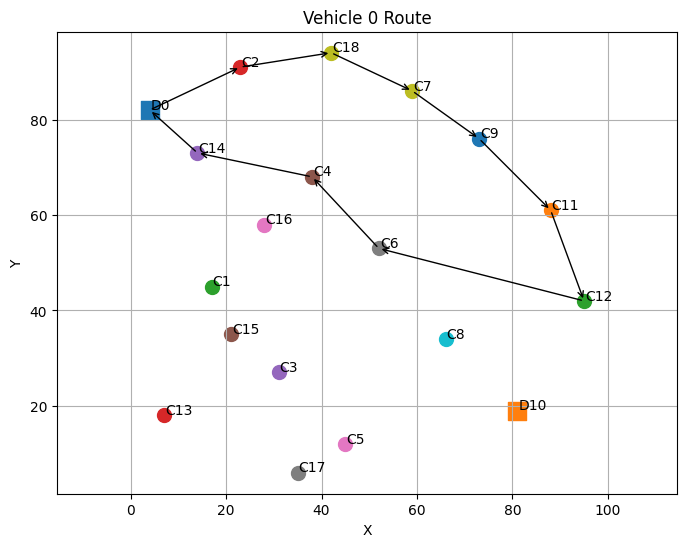

Vehicle 1: [10, 8, 16, 1, 15, 3, 13, 17, 5, 10]


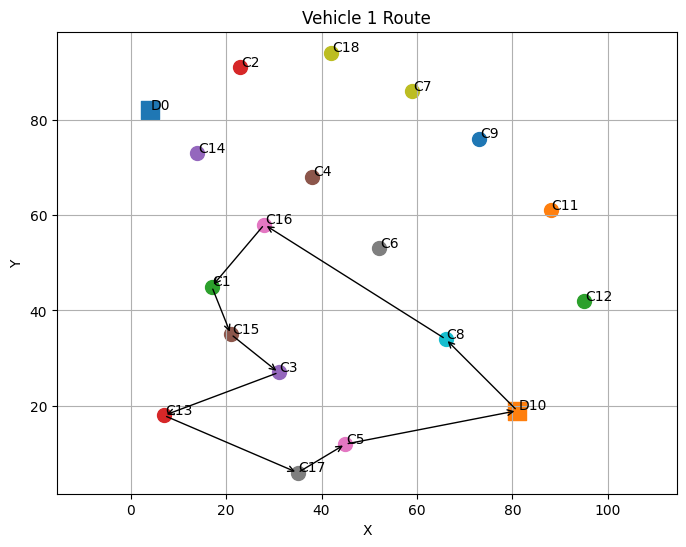

In [14]:
# Directly copy-pasted this part from AI
import matplotlib.pyplot as plt

coords = nodes

for k in K:
    arcs = [(i, j) for i in N for j in N
            if i != j and (i, j, k) in x and solver.Value(x[i, j, k])]

    start = next((d for d in D if solver.Value(w[d, k])), None)
    if start is None:
        continue

    path, cur = [start], start
    while True:
        nxt = next((j for i, j in arcs if i == cur), None)
        if nxt is None: break
        path.append(nxt); cur = nxt
        if cur == start: break

    print(f"Vehicle {k}: {path}")

    plt.figure(figsize=(8, 6))

    for d in D:
        plt.scatter(*coords[d], marker="s", s=180)
        plt.text(coords[d][0]+.2, coords[d][1]+.2, f"D{d}")

    for i in C:
        plt.scatter(*coords[i], s=100)
        plt.text(coords[i][0]+.2, coords[i][1]+.2, f"C{i}")

    for i, j in zip(path, path[1:]):
        plt.annotate("", coords[j], coords[i],
                     arrowprops=dict(arrowstyle="->"))

    plt.title(f"Vehicle {k} Route")
    plt.xlabel("X"); plt.ylabel("Y")
    plt.grid(); plt.axis("equal"); plt.show()